# Fraud Detection in Internship Applications

## Objective
Identify anomalies and potentially fraudulent internship applications using
data analysis and machine learning.

### Techniques Used
- Duplicate detection
- Rapid submission analysis
- Data consistency checks
- Isolation Forest
- K-Means Clustering
- Suspicious application alerts

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
np.random.seed(42)

n = 100

data = {
    "Application_ID": [f"APP{1000+i}" for i in range(n)],
    
    "Applicant_Name": [f"Applicant_{i+1}" for i in range(n)],
    
    "Age": np.random.randint(20, 36, n),
    
    "Education": np.random.choice(
        ["Bachelor", "Master", "Diploma"],
        n,
        p=[0.55, 0.30, 0.15]
    ),
    
    "Experience_Years": np.random.randint(0, 7, n),
    
    "Skills_Count": np.random.randint(2, 11, n),
    
    "Applications_Submitted": np.random.randint(1, 6, n),
    
    "Submission_Hour": np.random.randint(0, 24, n),
    
    "Submission_Minute": np.random.randint(0, 60, n),
    
    "Time_Between_Submissions_Min": np.random.randint(1, 180, n),
    
    "Profile_Completion": np.random.randint(50, 101, n),
    
    "Phone_Verified": np.random.choice([0, 1], n, p=[0.15, 0.85]),
    
    "Email_Verified": np.random.choice([0, 1], n, p=[0.10, 0.90]),
    
    "Documents_Verified": np.random.choice([0, 1], n, p=[0.20, 0.80])
}

df = pd.DataFrame(data)

df.head()

,Application_ID,Applicant_Name,Age,Education,Experience_Years,Skills_Count,Applications_Submitted,Submission_Hour,Submission_Minute,Time_Between_Submissions_Min,Profile_Completion,Phone_Verified,Email_Verified,Documents_Verified
0,APP1000,Applicant_1,26,Diploma,0,10,4,8,16,155,53,1,1,1
1,APP1001,Applicant_2,23,Master,0,5,5,6,6,145,59,1,1,1
2,APP1002,Applicant_3,32,Diploma,2,2,2,3,24,161,66,1,1,1
3,APP1003,Applicant_4,34,Diploma,5,5,4,20,44,157,59,1,1,1
4,APP1004,Applicant_5,30,Master,1,2,2,17,3,141,66,0,1,1


In [3]:
# Create suspicious patterns

df.loc[5, "Applications_Submitted"] = 25
df.loc[5, "Time_Between_Submissions_Min"] = 1
df.loc[5, "Profile_Completion"] = 35
df.loc[5, "Phone_Verified"] = 0
df.loc[5, "Email_Verified"] = 0

df.loc[15, "Applications_Submitted"] = 20
df.loc[15, "Time_Between_Submissions_Min"] = 2
df.loc[15, "Profile_Completion"] = 40
df.loc[15, "Documents_Verified"] = 0

df.loc[25, "Age"] = 65
df.loc[25, "Experience_Years"] = 25
df.loc[25, "Applications_Submitted"] = 18

df.loc[35, "Skills_Count"] = 30
df.loc[35, "Applications_Submitted"] = 15
df.loc[35, "Time_Between_Submissions_Min"] = 1

df.loc[45, "Profile_Completion"] = 10
df.loc[45, "Phone_Verified"] = 0
df.loc[45, "Email_Verified"] = 0
df.loc[45, "Documents_Verified"] = 0

print("Suspicious patterns added.")

Suspicious patterns added.


In [4]:
df.to_csv("internship_applications.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!


In [5]:
df.isnull().sum()

Application_ID                  0
Applicant_Name                  0
Age                             0
Education                       0
Experience_Years                0
Skills_Count                    0
Applications_Submitted          0
Submission_Hour                 0
Submission_Minute               0
Time_Between_Submissions_Min    0
Profile_Completion              0
Phone_Verified                  0
Email_Verified                  0
Documents_Verified              0
dtype: int64

In [6]:
duplicate_count = df.duplicated().sum()

print("Duplicate applications:", duplicate_count)

Duplicate applications: 0


In [7]:
duplicate_names = df["Applicant_Name"].duplicated().sum()

print("Duplicate applicant names:", duplicate_names)

Duplicate applicant names: 0


In [8]:
df["Rapid_Submission_Flag"] = np.where(
    df["Time_Between_Submissions_Min"] <= 5, 1, 0
)

df["High_Application_Flag"] = np.where(
    df["Applications_Submitted"] >= 10, 1, 0
)

df["Verification_Flag"] = np.where(
    (df["Phone_Verified"] == 0) |
    (df["Email_Verified"] == 0) |
    (df["Documents_Verified"] == 0),
    1,
    0
)

df["Data_Consistency_Flag"] = np.where(
    (df["Age"] > 50) |
    (df["Experience_Years"] > 15) |
    (df["Skills_Count"] > 20),
    1,
    0
)

df.head()

,Application_ID,Applicant_Name,Age,Education,Experience_Years,Skills_Count,Applications_Submitted,Submission_Hour,Submission_Minute,Time_Between_Submissions_Min,Profile_Completion,Phone_Verified,Email_Verified,Documents_Verified,Rapid_Submission_Flag,High_Application_Flag,Verification_Flag,Data_Consistency_Flag
0,APP1000,Applicant_1,26,Diploma,0,10,4,8,16,155,53,1,1,1,0,0,0,0
1,APP1001,Applicant_2,23,Master,0,5,5,6,6,145,59,1,1,1,0,0,0,0
2,APP1002,Applicant_3,32,Diploma,2,2,2,3,24,161,66,1,1,1,0,0,0,0
3,APP1003,Applicant_4,34,Diploma,5,5,4,20,44,157,59,1,1,1,0,0,0,0
4,APP1004,Applicant_5,30,Master,1,2,2,17,3,141,66,0,1,1,0,0,1,0


In [9]:
df["Fraud_Risk_Score"] = (
    df["Rapid_Submission_Flag"] +
    df["High_Application_Flag"] +
    df["Verification_Flag"] +
    df["Data_Consistency_Flag"]
)

df[[
    "Application_ID",
    "Fraud_Risk_Score",
    "Rapid_Submission_Flag",
    "High_Application_Flag",
    "Verification_Flag",
    "Data_Consistency_Flag"
]].head(10)

,Application_ID,Fraud_Risk_Score,Rapid_Submission_Flag,High_Application_Flag,Verification_Flag,Data_Consistency_Flag
0,APP1000,0,0,0,0,0
1,APP1001,0,0,0,0,0
2,APP1002,0,0,0,0,0
3,APP1003,0,0,0,0,0
4,APP1004,1,0,0,1,0
5,APP1005,3,1,1,1,0
6,APP1006,0,0,0,0,0
7,APP1007,0,0,0,0,0
8,APP1008,0,0,0,0,0
9,APP1009,1,0,0,1,0


In [10]:
features = [
    "Age",
    "Experience_Years",
    "Skills_Count",
    "Applications_Submitted",
    "Submission_Hour",
    "Submission_Minute",
    "Time_Between_Submissions_Min",
    "Profile_Completion",
    "Phone_Verified",
    "Email_Verified",
    "Documents_Verified"
]

X = df[features]

print("Features selected:", len(features))

Features selected: 11


In [11]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Data standardized successfully!")

Data standardized successfully!


In [12]:
isolation_forest = IsolationForest(
    contamination=0.10,
    random_state=42
)

isolation_forest.fit(X_scaled)

,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",None
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ndom_state=42)


In [13]:
df["Isolation_Result"] = isolation_forest.predict(X_scaled)

In [14]:
df["Isolation_Anomaly"] = np.where(
    df["Isolation_Result"] == -1,
    1,
    0
)

df[[
    "Application_ID",
    "Isolation_Result",
    "Isolation_Anomaly"
]].head(10)

,Application_ID,Isolation_Result,Isolation_Anomaly
0,APP1000,1,0
1,APP1001,1,0
2,APP1002,1,0
3,APP1003,1,0
4,APP1004,1,0
5,APP1005,-1,1
6,APP1006,1,0
7,APP1007,1,0
8,APP1008,1,0
9,APP1009,-1,1


In [15]:
df["Anomaly_Score"] = isolation_forest.decision_function(X_scaled)

df[[
    "Application_ID",
    "Anomaly_Score"
]].head()

,Application_ID,Anomaly_Score
0,APP1000,0.066784
1,APP1001,0.081928
2,APP1002,0.103498
3,APP1003,0.087962
4,APP1004,0.037611


In [16]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

df[[
    "Application_ID",
    "Cluster"
]].head(10)

C:\Users\drsid\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,Application_ID,Cluster
0,APP1000,0
1,APP1001,0
2,APP1002,0
3,APP1003,0
4,APP1004,0
5,APP1005,2
6,APP1006,0
7,APP1007,0
8,APP1008,0
9,APP1009,2


In [17]:
cluster_summary = df.groupby("Cluster")[features].mean()

cluster_summary

,Age,Experience_Years,Skills_Count,Applications_Submitted,Submission_Hour,Submission_Minute,Time_Between_Submissions_Min,Profile_Completion,Phone_Verified,Email_Verified,Documents_Verified
Cluster,,,,,,,,,,,
0,27.376471,2.494118,6.047059,3.188235,12.129412,29.635294,86.752941,75.435294,0.870588,0.929412,1.000000
1,65.000000,25.000000,2.000000,18.000000,4.000000,27.000000,26.000000,89.000000,0.000000,1.000000,1.000000
2,28.000000,3.857143,5.357143,6.000000,10.642857,35.500000,84.785714,61.500000,0.714286,0.785714,0.071429


In [18]:
cluster_risk = df.groupby("Cluster")["Fraud_Risk_Score"].mean()

print(cluster_risk)

Cluster
0    0.282353
1    3.000000
2    1.357143
Name: Fraud_Risk_Score, dtype: float64


In [19]:
high_risk_cluster = cluster_risk.idxmax()

print("Highest-risk cluster:", high_risk_cluster)

Highest-risk cluster: 1


In [20]:
df["KMeans_Suspicious"] = np.where(
    df["Cluster"] == high_risk_cluster,
    1,
    0
)

In [21]:
df["Suspicion_Score"] = (
    df["Fraud_Risk_Score"] +
    df["Isolation_Anomaly"] +
    df["KMeans_Suspicious"]
)

df[[
    "Application_ID",
    "Fraud_Risk_Score",
    "Isolation_Anomaly",
    "KMeans_Suspicious",
    "Suspicion_Score"
]].head(10)

,Application_ID,Fraud_Risk_Score,Isolation_Anomaly,KMeans_Suspicious,Suspicion_Score
0,APP1000,0,0,0,0
1,APP1001,0,0,0,0
2,APP1002,0,0,0,0
3,APP1003,0,0,0,0
4,APP1004,1,0,0,1
5,APP1005,3,1,0,4
6,APP1006,0,0,0,0
7,APP1007,0,0,0,0
8,APP1008,0,0,0,0
9,APP1009,1,1,0,2


In [22]:
def classify_risk(score):
    if score >= 4:
        return "High Risk"
    elif score >= 2:
        return "Medium Risk"
    else:
        return "Low Risk"

df["Risk_Level"] = df["Suspicion_Score"].apply(classify_risk)

df[
    [
        "Application_ID",
        "Applicant_Name",
        "Suspicion_Score",
        "Risk_Level"
    ]
].head(20)

,Application_ID,Applicant_Name,Suspicion_Score,Risk_Level
0,APP1000,Applicant_1,0,Low Risk
1,APP1001,Applicant_2,0,Low Risk
2,APP1002,Applicant_3,0,Low Risk
3,APP1003,Applicant_4,0,Low Risk
4,APP1004,Applicant_5,1,Low Risk
5,APP1005,Applicant_6,4,High Risk
6,APP1006,Applicant_7,0,Low Risk
7,APP1007,Applicant_8,0,Low Risk
8,APP1008,Applicant_9,0,Low Risk
9,APP1009,Applicant_10,2,Medium Risk


In [23]:
high_risk = df[df["Risk_Level"] == "High Risk"]

print("High-risk applications:", len(high_risk))

high_risk[[
    "Application_ID",
    "Applicant_Name",
    "Age",
    "Applications_Submitted",
    "Time_Between_Submissions_Min",
    "Profile_Completion",
    "Phone_Verified",
    "Email_Verified",
    "Documents_Verified",
    "Risk_Level"
]]

High-risk applications: 4


,Application_ID,Applicant_Name,Age,Applications_Submitted,Time_Between_Submissions_Min,Profile_Completion,Phone_Verified,Email_Verified,Documents_Verified,Risk_Level
5,APP1005,Applicant_6,27,25,1,35,0,0,1,High Risk
15,APP1015,Applicant_16,24,20,2,40,1,1,0,High Risk
25,APP1025,Applicant_26,65,18,26,89,0,1,1,High Risk
35,APP1035,Applicant_36,32,15,1,100,0,1,1,High Risk


In [24]:
def generate_alert(row):
    
    alerts = []
    
    if row["Applications_Submitted"] >= 10:
        alerts.append("Excessive applications")
    
    if row["Time_Between_Submissions_Min"] <= 5:
        alerts.append("Rapid submissions")
    
    if row["Phone_Verified"] == 0:
        alerts.append("Phone not verified")
    
    if row["Email_Verified"] == 0:
        alerts.append("Email not verified")
    
    if row["Documents_Verified"] == 0:
        alerts.append("Documents not verified")
    
    if row["Age"] > 50:
        alerts.append("Unusual age")
    
    if row["Experience_Years"] > 15:
        alerts.append("Unusual experience")
    
    if row["Skills_Count"] > 20:
        alerts.append("Unusual skill count")
    
    return ", ".join(alerts)

df["Alert_Message"] = df.apply(generate_alert, axis=1)

In [25]:
alerts = df[df["Alert_Message"] != ""]

alerts[[
    "Application_ID",
    "Applicant_Name",
    "Risk_Level",
    "Alert_Message"
]].head(20)

,Application_ID,Applicant_Name,Risk_Level,Alert_Message
4,APP1004,Applicant_5,Low Risk,Phone not verified
5,APP1005,Applicant_6,High Risk,"Excessive applications, Rapid submissions, Pho..."
9,APP1009,Applicant_10,Medium Risk,"Email not verified, Documents not verified"
15,APP1015,Applicant_16,High Risk,"Excessive applications, Rapid submissions, Doc..."
16,APP1016,Applicant_17,Low Risk,Rapid submissions
25,APP1025,Applicant_26,High Risk,"Excessive applications, Phone not verified, Un..."
28,APP1028,Applicant_29,Low Risk,Documents not verified
30,APP1030,Applicant_31,Medium Risk,"Phone not verified, Documents not verified"
32,APP1032,Applicant_33,Low Risk,Phone not verified
34,APP1034,Applicant_35,Low Risk,Phone not verified


In [26]:
risk_counts = df["Risk_Level"].value_counts()

print(risk_counts)

Risk_Level
Low Risk       88
Medium Risk     8
High Risk       4
Name: count, dtype: int64


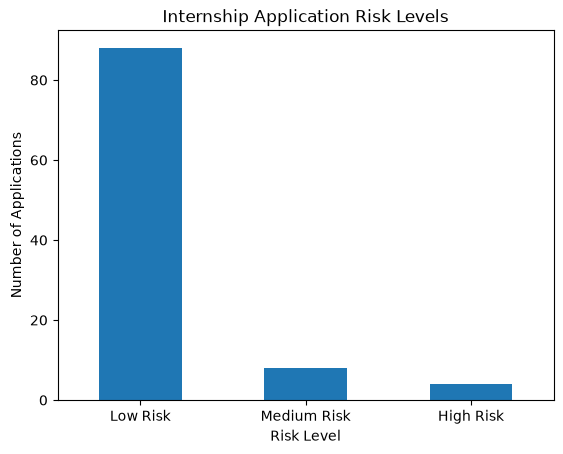

In [27]:
risk_counts.plot(kind="bar")

plt.title("Internship Application Risk Levels")
plt.xlabel("Risk Level")
plt.ylabel("Number of Applications")
plt.xticks(rotation=0)
plt.show()

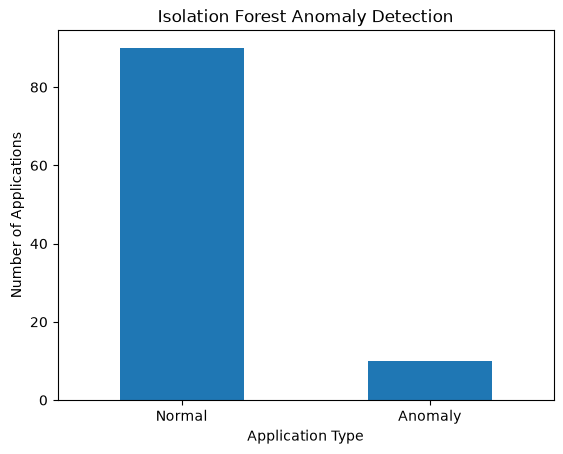

In [28]:
anomaly_counts = df["Isolation_Anomaly"].value_counts()

anomaly_counts.index = [
    "Normal" if x == 0 else "Anomaly"
    for x in anomaly_counts.index
]

anomaly_counts.plot(kind="bar")

plt.title("Isolation Forest Anomaly Detection")
plt.xlabel("Application Type")
plt.ylabel("Number of Applications")
plt.xticks(rotation=0)
plt.show()

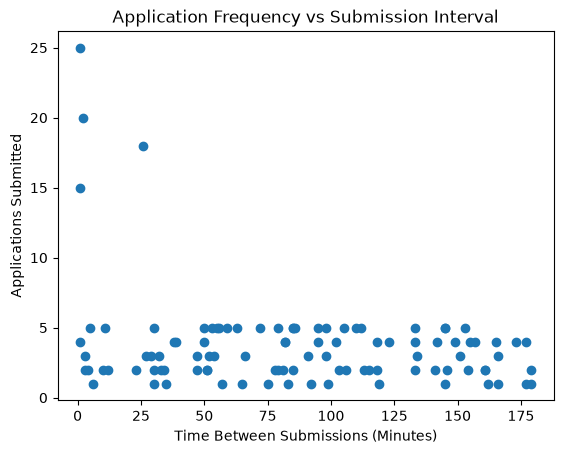

In [29]:
plt.scatter(
    df["Time_Between_Submissions_Min"],
    df["Applications_Submitted"]
)

plt.title("Application Frequency vs Submission Interval")
plt.xlabel("Time Between Submissions (Minutes)")
plt.ylabel("Applications Submitted")

plt.show()

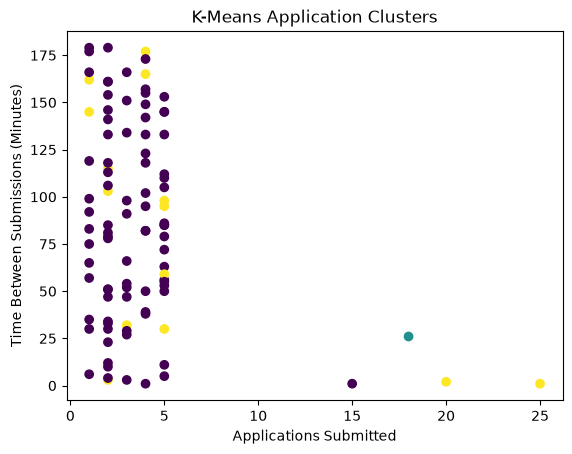

In [30]:
plt.scatter(
    df["Applications_Submitted"],
    df["Time_Between_Submissions_Min"],
    c=df["Cluster"]
)

plt.title("K-Means Application Clusters")
plt.xlabel("Applications Submitted")
plt.ylabel("Time Between Submissions (Minutes)")

plt.show()

In [31]:
fraud_report = df[[
    "Application_ID",
    "Applicant_Name",
    "Age",
    "Education",
    "Experience_Years",
    "Skills_Count",
    "Applications_Submitted",
    "Time_Between_Submissions_Min",
    "Profile_Completion",
    "Phone_Verified",
    "Email_Verified",
    "Documents_Verified",
    "Fraud_Risk_Score",
    "Anomaly_Score",
    "Cluster",
    "Isolation_Anomaly",
    "KMeans_Suspicious",
    "Suspicion_Score",
    "Risk_Level",
    "Alert_Message"
]]

fraud_report.head()

,Application_ID,Applicant_Name,Age,Education,Experience_Years,Skills_Count,Applications_Submitted,Time_Between_Submissions_Min,Profile_Completion,Phone_Verified,Email_Verified,Documents_Verified,Fraud_Risk_Score,Anomaly_Score,Cluster,Isolation_Anomaly,KMeans_Suspicious,Suspicion_Score,Risk_Level,Alert_Message
0,APP1000,Applicant_1,26,Diploma,0,10,4,155,53,1,1,1,0,0.066784,0,0,0,0,Low Risk,
1,APP1001,Applicant_2,23,Master,0,5,5,145,59,1,1,1,0,0.081928,0,0,0,0,Low Risk,
2,APP1002,Applicant_3,32,Diploma,2,2,2,161,66,1,1,1,0,0.103498,0,0,0,0,Low Risk,
3,APP1003,Applicant_4,34,Diploma,5,5,4,157,59,1,1,1,0,0.087962,0,0,0,0,Low Risk,
4,APP1004,Applicant_5,30,Master,1,2,2,141,66,0,1,1,1,0.037611,0,0,0,1,Low Risk,Phone not verified


In [32]:
fraud_report.to_csv(
    "fraud_detection_report.csv",
    index=False
)

print("Fraud detection report saved!")

Fraud detection report saved!


In [33]:
suspicious_applications = fraud_report[
    fraud_report["Risk_Level"].isin(
        ["High Risk", "Medium Risk"]
    )
]

suspicious_applications.to_csv(
    "suspicious_applications.csv",
    index=False
)

print(
    "Suspicious applications:",
    len(suspicious_applications)
)

Suspicious applications: 12


# Project Insights

## Key Findings

1. Duplicate and repeated application patterns can indicate suspicious activity.

2. Rapid submissions within a very short time period were identified as an important
fraud indicator.

3. Applications with unusually high submission counts received higher risk scores.

4. Missing phone, email, or document verification increased the application's
suspicion level.

5. Isolation Forest was used to identify unusual application behavior.

6. K-Means Clustering was used to group applications according to behavioral patterns.

7. A combined suspicion score was created using rule-based indicators,
Isolation Forest results, and K-Means clustering.

8. High-risk applications were automatically flagged for further manual review.

## Conclusion

The project demonstrates how machine learning and data analysis can help internship
programs identify potentially fraudulent or abnormal applications. The system does
not automatically declare an applicant fraudulent; instead, it generates alerts that
can be reviewed by administrators.